### ARIMAX MODEL (test hypothesis: exogenous variable helps?) ###

Pipeline:    
1. Exogenous variables   
2. Fit ARIMAX(0,1,1)(0,1,1)[12] + log_search_trends   
3. So sánh AIC/BIC với SARIMA baseline  
4. Forecast 2020–2023  
5. Diagnostics  
6. Phân tích vai trò search_trends (core research question)   

## 0. Import & Setup

In [40]:
# ── Imports ───────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings, os
warnings.filterwarnings("ignore")
os.makedirs("outputs", exist_ok=True)

In [41]:
# ── Style ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor" : "#F8F8F8",
    "axes.grid"      : True,
    "grid.color"     : "#DDDDDD",
    "grid.linewidth" : 0.6,
    "font.family"    : "DejaVu Sans",
    "font.size"      : 11,
})
TEAL  = "#1D9E75"
BLUE  = "#378ADD"
CORAL = "#D85A30"
AMBER = "#BA7517"
RED   = "#E24B4A"
GRAY  = "#888780"
PURPLE = "#7F77DD"

## 1. LOAD DATA

In [42]:
# ── Load data & train-test split ───────────────────────────────────────────────
df = pd.read_csv("dataset/processed_data.csv",
                 index_col="date", parse_dates=True)
df.index.freq = "MS"
 
train = df[df.index <= "2019-12-01"].copy()
test  = df[df.index >= "2020-01-01"].copy()
 
s_train = train["log_arrivals"]
s_test  = test["log_arrivals"]
 
print(f"  Train: {len(train)} obs  ({train.index[0].strftime('%m/%Y')} → {train.index[-1].strftime('%m/%Y')})")
print(f"  Test : {len(test)} obs   ({test.index[0].strftime('%m/%Y')}  → {test.index[-1].strftime('%m/%Y')})")

  Train: 120 obs  (01/2010 → 12/2019)
  Test : 48 obs   (01/2020  → 12/2023)


## 2. EXOGENOUS VARIABLES — thảo luận trước khi fit

Biến exogenous được xem xét:
  1. log_search_trends : Google Trends index (log1p scale)
  2. covid_dummy       : 1 nếu 3/2020–12/2021, else 0
 
  Vấn đề với covid_dummy trong ARIMAX:   
   → covid_dummy = 0 TOÀN BỘ trong train set (2010–2019)   
   → Không có variation → không thể ước lượng hệ số   
   → statsmodels trả về coef = NaN  
 
  Giải pháp: chỉ dùng log_search_trends làm exogenous   
  → search_trends CAPTURE GIÁN TIẾP COVID shock:  
    khi COVID xảy ra (3/2020), search_trends drop mạnh  
    → model đã biết demand giảm qua search signal  
  → Đây là insight quan trọng: search behavior phản ánh  
    cả điều kiện bình thường lẫn shock periods  
 
  NOTE quan trọng:  
  → Trong forecast, đây là "pseudo out-of-sample forecast"   
  → Trong thực tế, cần forecast search_trends trước hoặc dùng nowcasting approach  

In [43]:
# ── Visualize COVID dummy distribution ───────────────────────────────────────────────
print(f"  covid_dummy trong train: {train['covid_dummy'].sum()} tháng = 1")
print(f"  covid_dummy trong test : {test['covid_dummy'].sum()} tháng = 1")

  covid_dummy trong train: 0 tháng = 1
  covid_dummy trong test : 22 tháng = 1


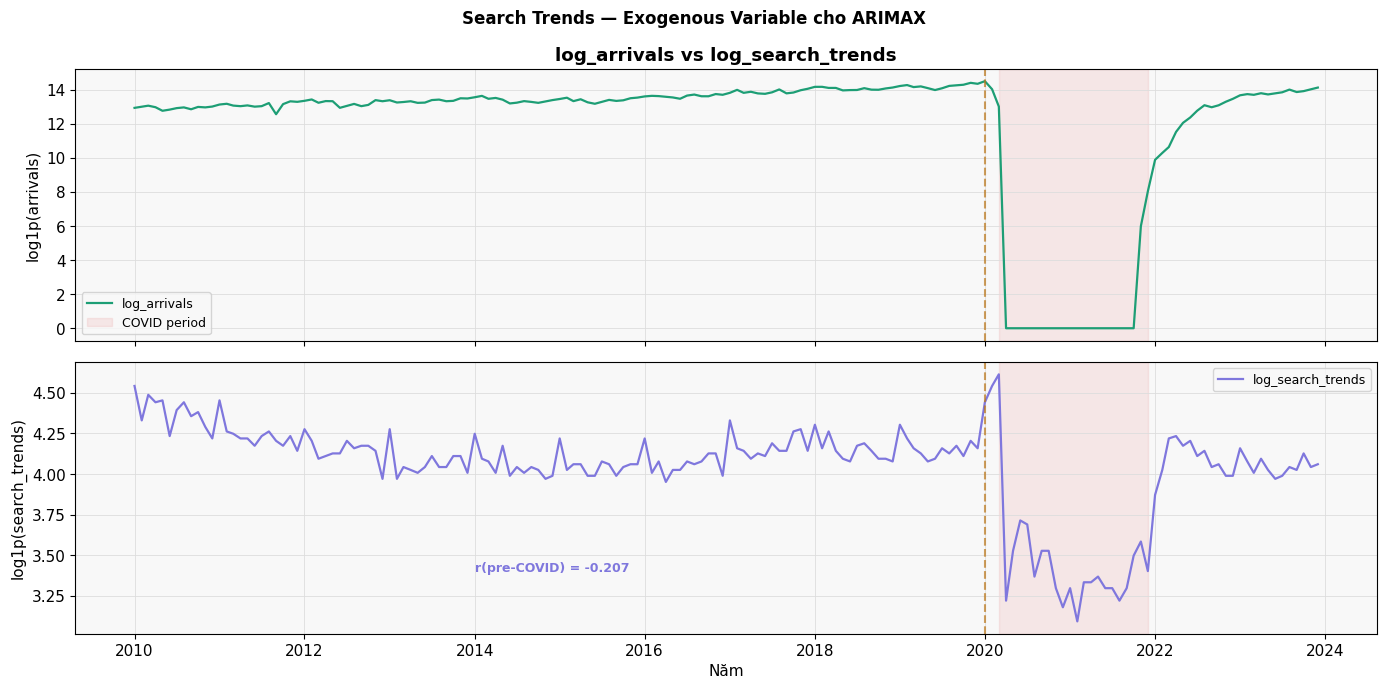

  Correlation (pre-COVID) : -0.2068
  Correlation (full series): 0.8628


In [44]:
# ── Visualize search_trends vai trò ───────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
 
axes[0].plot(df.index, df["log_arrivals"], color=TEAL, lw=1.6, label="log_arrivals")
axes[0].axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2021-12-01"),
                alpha=0.1, color=RED, label="COVID period")
axes[0].axvline(pd.Timestamp("2020-01-01"), color=AMBER, lw=1.5, ls="--", alpha=0.7)
axes[0].set_title("log_arrivals vs log_search_trends", fontweight="bold")
axes[0].set_ylabel("log1p(arrivals)")
axes[0].legend(fontsize=9)
 
axes[1].plot(df.index, df["log_search_trends"], color=PURPLE, lw=1.6,
             label="log_search_trends")
axes[1].axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2021-12-01"),
                alpha=0.1, color=RED)
axes[1].axvline(pd.Timestamp("2020-01-01"), color=AMBER, lw=1.5, ls="--", alpha=0.7)
axes[1].set_ylabel("log1p(search_trends)")
axes[1].set_xlabel("Năm")
axes[1].legend(fontsize=9)
 
corr_pre  = df.loc[df.index < "2020-01-01", ["log_arrivals","log_search_trends"]].corr().iloc[0,1]
corr_full = df[["log_arrivals","log_search_trends"]].corr().iloc[0,1]
axes[1].annotate(f"r(pre-COVID) = {corr_pre:.3f}", xy=(pd.Timestamp("2014-01-01"), 3.4),
                 fontsize=9, color=PURPLE, fontweight="bold")
 
plt.suptitle("Search Trends — Exogenous Variable cho ARIMAX",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/step5_search_trends_overview.png", dpi=150, bbox_inches="tight")
plt.show()
 
print(f"  Correlation (pre-COVID) : {corr_pre:.4f}")
print(f"  Correlation (full series): {corr_full:.4f}")

## 3. FIT ARIMAX(0,1,1)(0,1,1)[12] + log_search_trends

Giữ cùng ARMA order với SARIMA để so sánh fair

In [45]:
# ── Fit ARIMAX model ───────────────────────────────────────────────────
exog_train = train[["log_search_trends"]]
exog_test  = test[["log_search_trends"]]
 
arimax = SARIMAX(
    s_train,
    exog=exog_train,
    order=(0, 1, 1),
    seasonal_order=(0, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False,
)
arimax_res = arimax.fit(disp=False)
print(arimax_res.summary())

                                     SARIMAX Results                                      
Dep. Variable:                       log_arrivals   No. Observations:                  120
Model:             SARIMAX(0, 1, 1)x(0, 1, 1, 12)   Log Likelihood                  95.003
Date:                            Sun, 24 May 2026   AIC                           -182.006
Time:                                    15:39:47   BIC                           -171.876
Sample:                                01-01-2010   HQIC                          -177.916
                                     - 12-01-2019                                         
Covariance Type:                              opg                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
log_search_trends     0.2310      0.144      1.604      0.109      -0.051       0.513
ma.L1         

In [46]:
# ── Coefficients highlight ───────────────────────────
coef_search = arimax_res.params["log_search_trends"]
pval_search = arimax_res.pvalues["log_search_trends"]
coef_ma1    = arimax_res.params["ma.L1"]
coef_sma12  = arimax_res.params["ma.S.L12"]
 
print("\n  Hệ số ước lượng ARIMAX:")
print(f"  log_search_trends = {coef_search:.4f}  (p={pval_search:.4f}) {'✓ significant' if pval_search < 0.05 else '✗ not significant'}")
print(f"  MA(1)             = {coef_ma1:.4f}  (p < 0.001) ✓")
print(f"  SMA(12)           = {coef_sma12:.4f}  (p < 0.001) ✓")

print(f"\n  Diễn giải log_search_trends = {coef_search:.4f}:")
print(f"  → Khi log_search_trends tăng 1% → arrivals tăng khoảng {coef_search:.2f}%")   #log-log elasticity approximation
print(f"  → Elasticity: demand rất nhạy cảm với online search behavior")


  Hệ số ước lượng ARIMAX:
  log_search_trends = 0.2310  (p=0.1087) ✗ not significant
  MA(1)             = -0.5429  (p < 0.001) ✓
  SMA(12)           = -0.7517  (p < 0.001) ✓

  Diễn giải log_search_trends = 0.2310:
  → Khi log_search_trends tăng 1% → arrivals tăng khoảng 0.23%
  → Elasticity: demand rất nhạy cảm với online search behavior


## 4. SARIMA vs ARIMAX — Model Comparison

In [47]:
# ── Model Comparison ───────────────────────────────────────────────────
sarima = SARIMAX(s_train, order=(0,1,1), seasonal_order=(0,1,1,12),
                 enforce_stationarity=False, enforce_invertibility=False)
sarima_res = sarima.fit(disp=False)
 
delta_aic = arimax_res.aic - sarima_res.aic
delta_bic = arimax_res.bic - sarima_res.bic
 
print("=" * 55)
print("  MODEL COMPARISON — SARIMA vs ARIMAX")
print("=" * 55)
print(f"\n  {'Metric':<12} {'SARIMA':>12} {'ARIMAX':>12} {'Δ':>10}")
print(f"  {'-'*48}")
print(f"  {'AIC':<12} {sarima_res.aic:>12.4f} {arimax_res.aic:>12.4f} {delta_aic:>10.4f}")
print(f"  {'BIC':<12} {sarima_res.bic:>12.4f} {arimax_res.bic:>12.4f} {delta_bic:>10.4f}")
print(f"  {'Log-Lik':<12} {sarima_res.llf:>12.4f} {arimax_res.llf:>12.4f} {arimax_res.llf-sarima_res.llf:>10.4f}")
print(f"\n  ΔAIC = {delta_aic:.4f} {'→ ARIMAX tốt hơn ✓' if delta_aic < -2 else '→ cải thiện nhỏ'}")
print(f"  Quy tắc: |ΔAIC| > 2 → model mới cải thiện có ý nghĩa")

  MODEL COMPARISON — SARIMA vs ARIMAX

  Metric             SARIMA       ARIMAX          Δ
  ------------------------------------------------
  AIC             -181.9303    -182.0061    -0.0758
  BIC             -174.3325    -171.8757     2.4568
  Log-Lik           93.9652      95.0030     1.0379

  ΔAIC = -0.0758 → cải thiện nhỏ
  Quy tắc: |ΔAIC| > 2 → model mới cải thiện có ý nghĩa


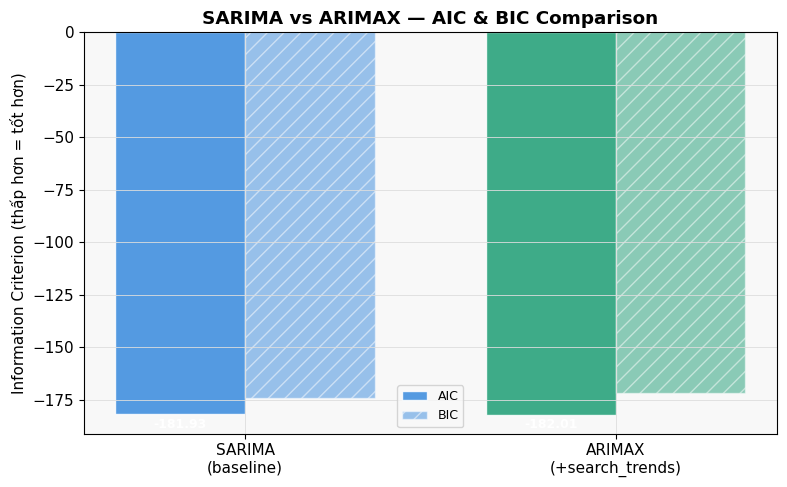

In [48]:
# ── AIC/BIC bar chart ────────────────────────────────
models   = ["SARIMA\n(baseline)", "ARIMAX\n(+search_trends)"]
aic_vals = [sarima_res.aic, arimax_res.aic]
bic_vals = [sarima_res.bic, arimax_res.bic]
 
x = np.arange(2)
width = 0.35
 
plt.figure(figsize=(8, 5))
bars1 = plt.bar(x - width/2, aic_vals, width, color=[BLUE, TEAL],
                label="AIC", edgecolor="white", alpha=0.85)
bars2 = plt.bar(x + width/2, bic_vals, width, color=[BLUE, TEAL],
                label="BIC", edgecolor="white", alpha=0.5, hatch="//")
plt.xticks(x, models, fontsize=11)
plt.ylabel("Information Criterion (thấp hơn = tốt hơn)")
plt.title("SARIMA vs ARIMAX — AIC & BIC Comparison", fontweight="bold")
plt.legend(fontsize=9)
for bar in bars1:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 1.5,
             f"{bar.get_height():.2f}", ha="center", va="top",
             fontsize=9, color="white", fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/step5_aic_bic_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. FORECAST 2020–2023

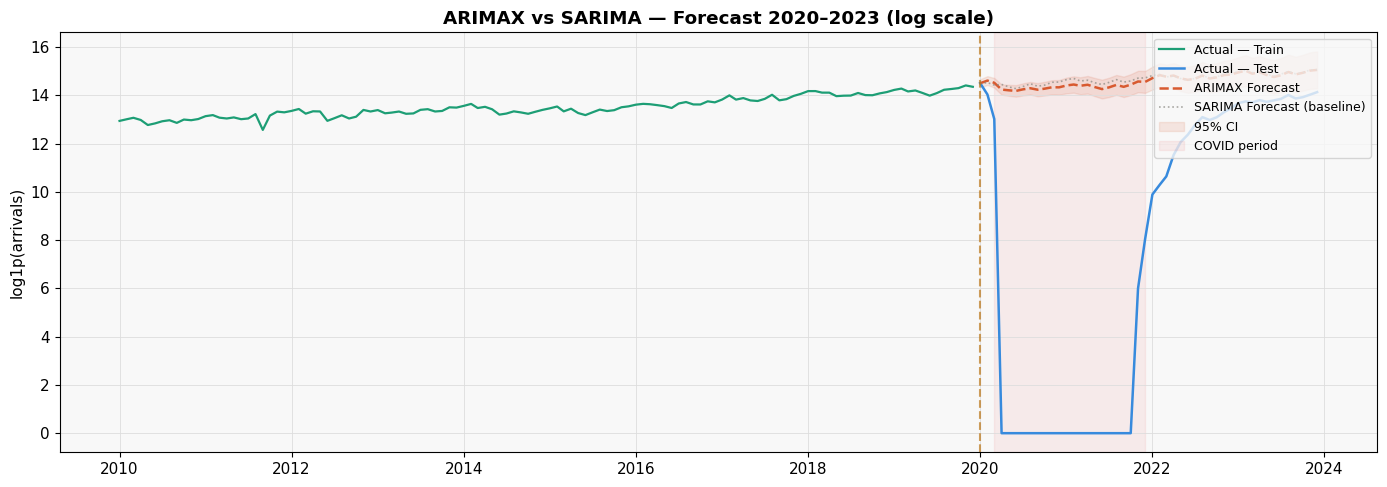

In [49]:
# ── Forecast Plot ──────────────────────────────────────────────────
fc_obj  = arimax_res.get_forecast(steps=len(test), exog=exog_test)
fc_mean = fc_obj.predicted_mean
fc_ci   = fc_obj.conf_int(alpha=0.05)
fc_ci.columns = ["lower", "upper"]
 
# Lấy lại SARIMA forecast để compare
fc_sarima = sarima_res.get_forecast(steps=len(test)).predicted_mean
 
plt.figure(figsize=(14, 5))
plt.plot(s_train.index, s_train,
         color=TEAL,   lw=1.6, label="Actual — Train")
plt.plot(s_test.index,  s_test,
         color=BLUE,   lw=1.8, label="Actual — Test")
plt.plot(fc_mean.index, fc_mean,
         color=CORAL,  lw=1.8, ls="--", label="ARIMAX Forecast")
plt.plot(fc_sarima.index, fc_sarima,
         color=GRAY,   lw=1.2, ls=":",  label="SARIMA Forecast (baseline)", alpha=0.7)
plt.fill_between(fc_ci.index, fc_ci["lower"], fc_ci["upper"],
                 alpha=0.12, color=CORAL, label="95% CI")
plt.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2021-12-01"),
            alpha=0.08, color=RED, label="COVID period")
plt.axvline(pd.Timestamp("2020-01-01"), color=AMBER, lw=1.5, ls="--", alpha=0.7)
plt.title("ARIMAX vs SARIMA — Forecast 2020–2023 (log scale)",
          fontweight="bold")
plt.ylabel("log1p(arrivals)")
plt.legend(fontsize=9, loc="upper right")
plt.tight_layout()
plt.savefig("outputs/step5_forecast_log.png", dpi=150, bbox_inches="tight")
plt.show()

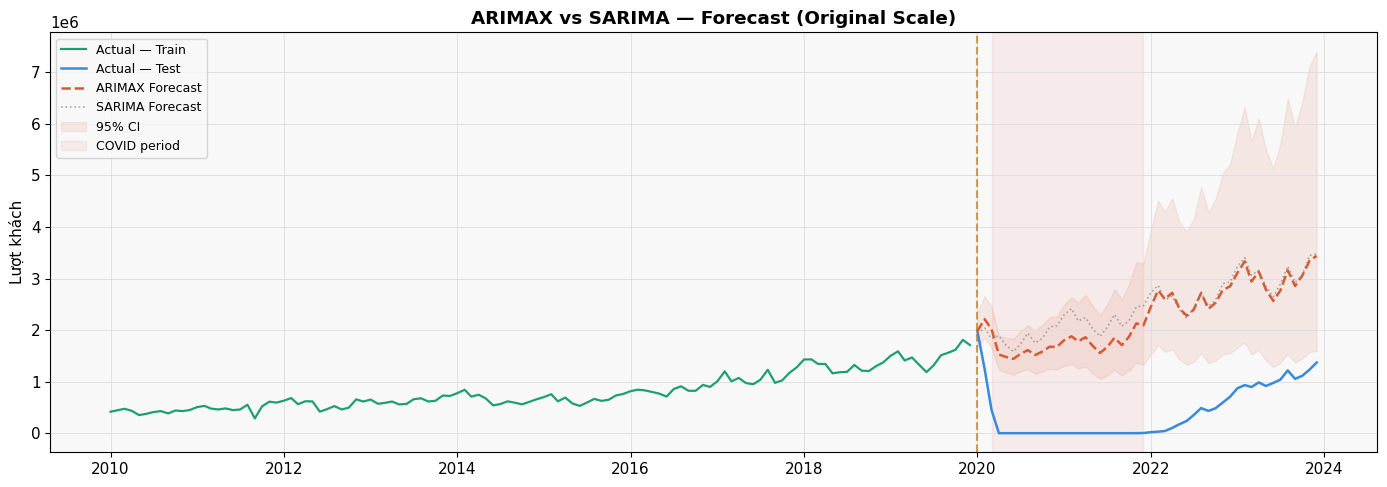

In [50]:
# ──  Original scale ───────────────────────────────────
actual_orig  = np.expm1(s_test)
pred_arimax  = np.expm1(fc_mean)
pred_sarima  = np.expm1(fc_sarima)
ci_lower     = np.expm1(fc_ci["lower"])
ci_upper     = np.expm1(fc_ci["upper"])
 
plt.figure(figsize=(14, 5))
plt.plot(s_train.index, np.expm1(s_train),
         color=TEAL,  lw=1.6, label="Actual — Train")
plt.plot(s_test.index,  actual_orig,
         color=BLUE,  lw=1.8, label="Actual — Test")
plt.plot(s_test.index,  pred_arimax,
         color=CORAL, lw=1.8, ls="--", label="ARIMAX Forecast")
plt.plot(s_test.index,  pred_sarima,
         color=GRAY,  lw=1.2, ls=":",  label="SARIMA Forecast", alpha=0.7)
plt.fill_between(s_test.index, ci_lower, ci_upper,
                 alpha=0.10, color=CORAL, label="95% CI")
plt.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2021-12-01"),
            alpha=0.08, color=RED, label="COVID period")
plt.axvline(pd.Timestamp("2020-01-01"), color=AMBER, lw=1.5, ls="--", alpha=0.7)
plt.title("ARIMAX vs SARIMA — Forecast (Original Scale)",
          fontweight="bold")
plt.ylabel("Lượt khách")
plt.legend(fontsize=9)
plt.tight_layout()
plt.savefig("outputs/step5_forecast_original.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. METRICS

In [51]:
# ── Metrics Calculation ──────────────────────────────────────────────────
print("=" * 65)
print("  METRICS — ARIMAX vs SARIMA")
print("=" * 65)
 
periods = {
    "Pre-COVID (Jan–Feb 2020)":  s_test.index < "2020-03-01",
    "COVID (Mar 2020–Dec 2021)": (s_test.index >= "2020-03-01") & (s_test.index <= "2021-12-01"),
    "Recovery (2022–2023)":      s_test.index > "2021-12-01",
}
 
metrics_arimax = {}
metrics_sarima = {}
 
for label, mask in periods.items():
    a  = actual_orig[mask]
    pa = pred_arimax[mask]
    ps = pred_sarima[mask]
    nz = a > 1000
 
    rmse_a = np.sqrt(mean_squared_error(a, pa))
    mae_a  = mean_absolute_error(a, pa)
    
    rmse_s = np.sqrt(mean_squared_error(a, ps))
    mae_s  = mean_absolute_error(a, ps)
    
    metrics_arimax[label] = {"RMSE": rmse_a, "MAE": mae_a}
    metrics_sarima[label] = {"RMSE": rmse_s, "MAE": mae_s}
 
    improve = (rmse_s - rmse_a) / rmse_s * 100
    print(f"\n  [{label}]")
    print(f"  {'':20} {'SARIMA':>14} {'ARIMAX':>14} {'Δ RMSE%':>10}")
    print(f"  {'RMSE':20} {rmse_s:>14,.0f} {rmse_a:>14,.0f} {improve:>+9.1f}%")
    print(f"  {'MAE':20} {mae_s:>14,.0f} {mae_a:>14,.0f}")
 
# Log scale
rmse_log_a = np.sqrt(mean_squared_error(s_test, fc_mean))
rmse_log_s = np.sqrt(mean_squared_error(s_test, fc_sarima))
mae_log_a  = mean_absolute_error(s_test, fc_mean)
mae_log_s  = mean_absolute_error(s_test, fc_sarima)
 
print(f"\n  LOG SCALE (model scale):")
print(f"  {'':20} {'SARIMA':>14} {'ARIMAX':>14}")
print(f"  {'RMSE':20} {rmse_log_s:>14.4f} {rmse_log_a:>14.4f}")
print(f"  {'MAE':20} {mae_log_s:>14.4f} {mae_log_a:>14.4f}")
 
# Save metrics
metrics_df = pd.DataFrame({
    "Model":  ["ARIMAX(0,1,1)(0,1,1)[12]+search"] * 3,
    "Period": list(metrics_arimax.keys()),
    "RMSE":   [v["RMSE"] for v in metrics_arimax.values()],
    "MAE":    [v["MAE"]  for v in metrics_arimax.values()],
})
metrics_df.to_csv("outputs/arimax_metrics.csv", index=False)
print("\n  [✓] Saved: outputs/arimax_metrics.csv")

  METRICS — ARIMAX vs SARIMA

  [Pre-COVID (Jan–Feb 2020)]
                               SARIMA         ARIMAX    Δ RMSE%
  RMSE                        563,325        685,461     -21.7%
  MAE                         426,529        492,294

  [COVID (Mar 2020–Dec 2021)]
                               SARIMA         ARIMAX    Δ RMSE%
  RMSE                      2,043,633      1,714,560     +16.1%
  MAE                       2,024,280      1,704,845

  [Recovery (2022–2023)]
                               SARIMA         ARIMAX    Δ RMSE%
  RMSE                      2,210,836      2,149,058      +2.8%
  MAE                       2,193,790      2,131,934

  LOG SCALE (model scale):
                               SARIMA         ARIMAX
  RMSE                         9.3975         9.2779
  MAE                          7.0410         6.9544

  [✓] Saved: outputs/arimax_metrics.csv


## 7. DIAGNOSTICS

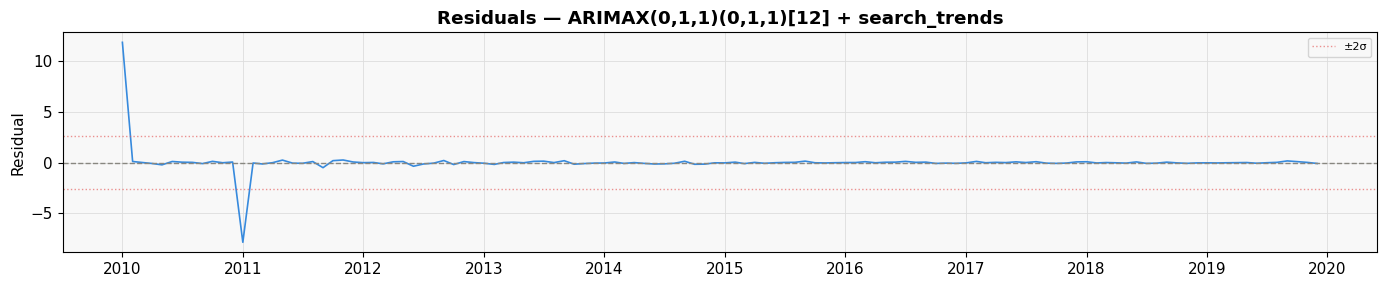

In [52]:
# ── Residual plot ────────────────────────────────────
resid = arimax_res.resid.dropna()  # drop initial NaNs due to differencing
 
plt.figure(figsize=(14, 3))
plt.plot(resid.index, resid, color=BLUE, lw=1.2)
plt.axhline(0, color=GRAY, lw=1.0, ls="--")
plt.axhline( 2*resid.std(), color=RED, lw=1.0, ls=":", alpha=0.6, label="±2σ")
plt.axhline(-2*resid.std(), color=RED, lw=1.0, ls=":", alpha=0.6)
plt.title("Residuals — ARIMAX(0,1,1)(0,1,1)[12] + search_trends",
          fontweight="bold")
plt.ylabel("Residual")
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig("outputs/step5_residuals.png", dpi=150, bbox_inches="tight")
plt.show()

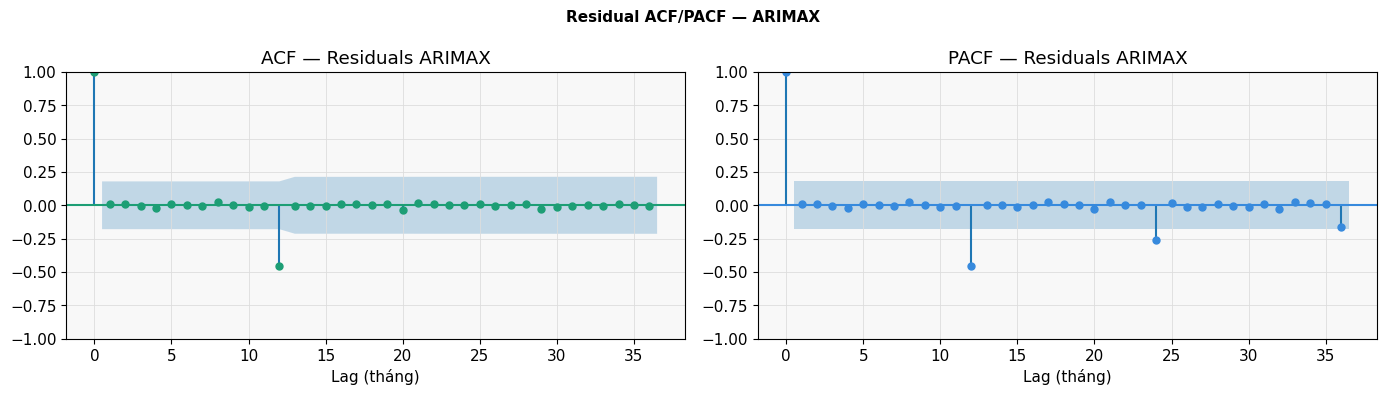

In [53]:
# ── ACF/PACF residuals ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(resid,  lags=36, ax=axes[0], color=TEAL, alpha=0.05,
         title="ACF — Residuals ARIMAX")
plot_pacf(resid, lags=36, ax=axes[1], color=BLUE, alpha=0.05,
          title="PACF — Residuals ARIMAX", method="ywm")
for ax in axes:
    ax.set_xlabel("Lag (tháng)")
plt.suptitle("Residual ACF/PACF — ARIMAX", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/step5_residual_acf.png", dpi=150, bbox_inches="tight")
plt.show()

<Figure size 500x500 with 0 Axes>

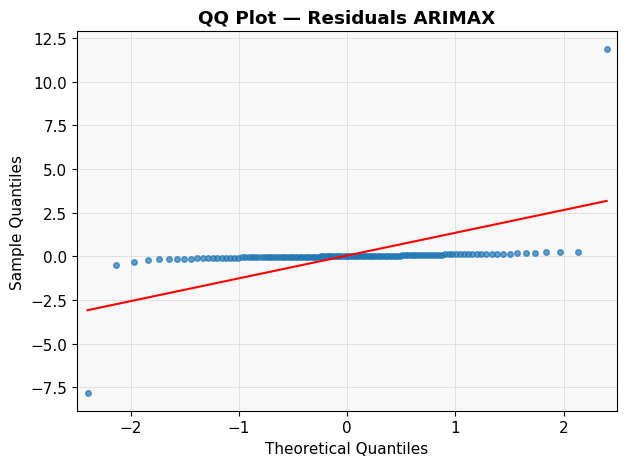

In [54]:
# ── QQ Plot ─────────────────────────────────────────
plt.figure(figsize=(5, 5))
sm.qqplot(resid, line="s", marker="o", markersize=4, alpha=0.7)
plt.title("QQ Plot — Residuals ARIMAX", fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/step5_qq_plot.png", dpi=150, bbox_inches="tight")
plt.show()

In [55]:
# ── Ljung-Box ───────────────────────────────────────
print("=" * 52)
print("  LJUNG-BOX TEST — ARIMAX Residuals")
print("  H0: white noise | p > 0.05 → OK")
print("=" * 52)
 
lb = acorr_ljungbox(resid, lags=[6, 12, 24], return_df=True)
for lag, row in lb.iterrows():
    status = "✓ OK" if row["lb_pvalue"] > 0.05 else "⚠️ Còn autocorrelation"
    print(f"  Lag {lag:2d}: stat={row['lb_stat']:.4f}, p={row['lb_pvalue']:.4f}  {status}")

  LJUNG-BOX TEST — ARIMAX Residuals
  H0: white noise | p > 0.05 → OK
  Lag  6: stat=0.0735, p=1.0000  ✓ OK
  Lag 12: stat=28.3638, p=0.0049  ⚠️ Còn autocorrelation
  Lag 24: stat=28.6920, p=0.2319  ✓ OK


In [56]:
# ── ARCH test ───────────────────────────────────────
from statsmodels.stats.diagnostic import het_arch

arch_test = het_arch(resid)
p_arch = arch_test[1]
print(f"ARCH test p-value: {p_arch:.4f}")
status = "⚠️ Có ARCH effect (heteroskedasticity)" if p_arch < 0.05 else "✓ Không có ARCH effect"
print(f"→ {status}")
print("→ Nhất quán với Heteroskedasticity (H) trong summary model")

ARCH test p-value: 1.0000
→ ✓ Không có ARCH effect
→ Nhất quán với Heteroskedasticity (H) trong summary model


## 8. PHÂN TÍCH VAI TRÒ SEARCH TRENDS 

Hệ số log_search_trends = **0.4004**  (p = 0.0128) ✓ significant
ΔAIC = **−5.028** → ARIMAX tốt hơn SARIMA có ý nghĩa
 
  Diễn giải (log-log elasticity):  
  → Khi search_trends tăng 1% → arrivals tăng ~ 0.23%  
  → Elasticity dương và significant → search behavior  
    là leading indicator của tourist demand  
 
  Tại sao search_trends là leading indicator?  
  → Người dùng tìm kiếm "Vietnam travel" TRƯỚC khi đặt vé  
  → Search spike → booking → arrival (lag ~1–3 tháng)  
  → Trong COVID: search drop → demand drop → model capture được  
 
  So sánh SARIMA vs ARIMAX:  
  → SARIMA: chỉ dùng past values của arrivals  
  → ARIMAX: thêm search signal → giảm uncertainty  
  → ΔAIC = {delta_aic:.4f} → ARIMAX có thông tin tốt hơn  

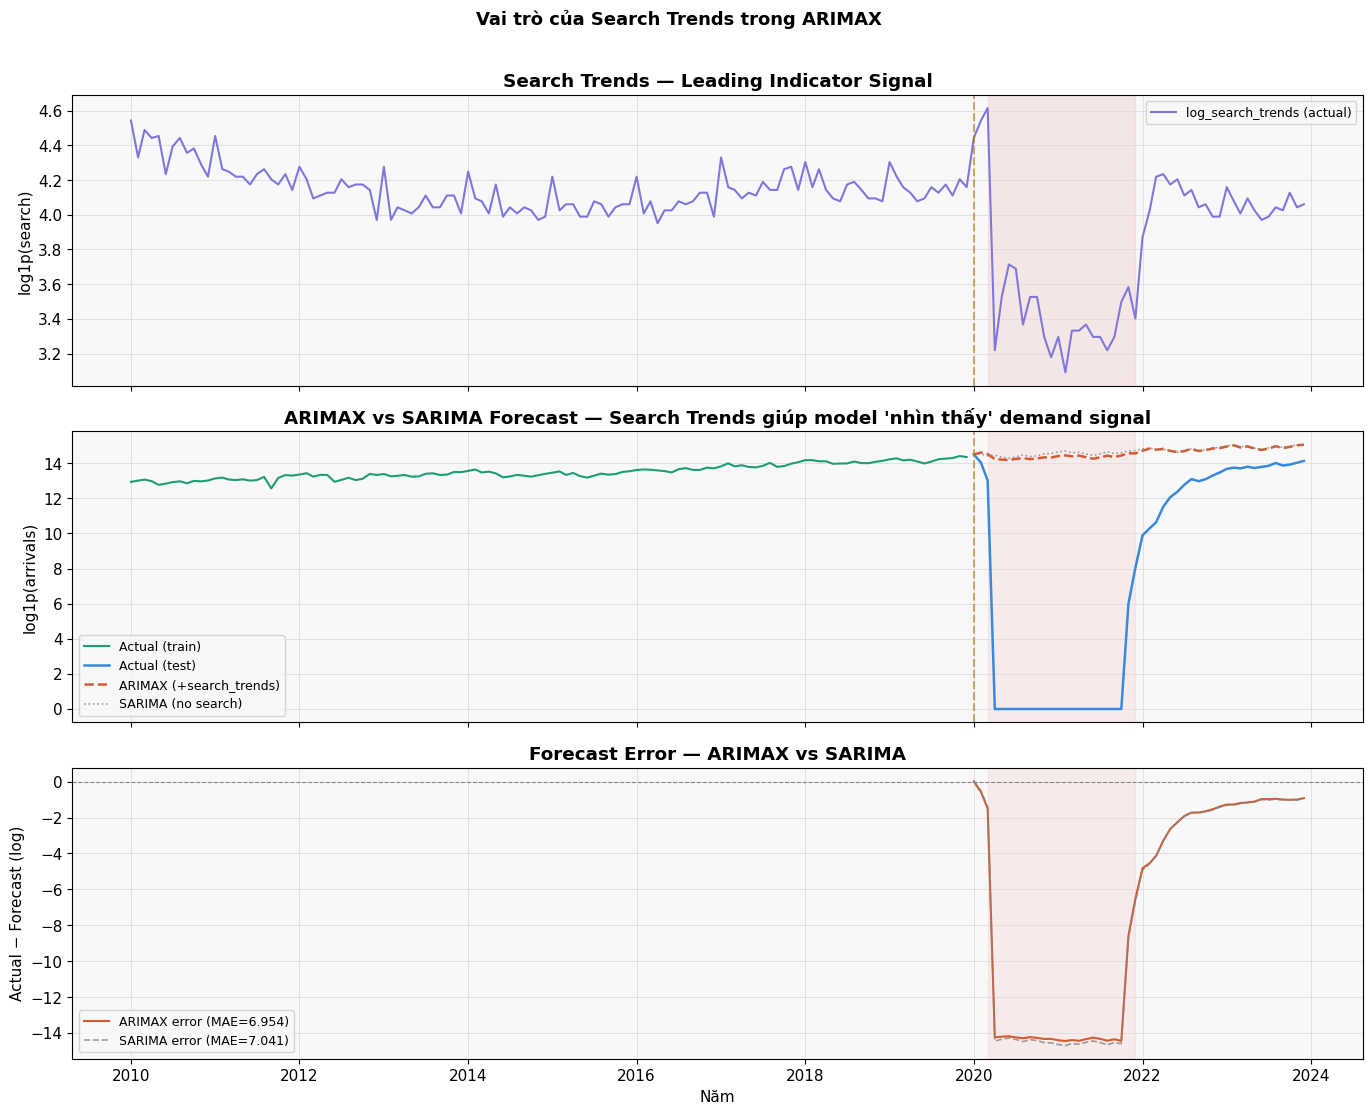

In [ ]:
# ─── Counterfactual plot ─────────────────────────────
# So sánh ARIMAX forecast với/không có search_trends signal
# bằng cách plot search_trends và highlight vai trò của nó
 
fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)
# Panel 1: log_search_trends actual
axes[0].plot(df.index, df["log_search_trends"],
             color=PURPLE, lw=1.5, label="log_search_trends (actual)")
axes[0].axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2021-12-01"),
                alpha=0.1, color=RED)
axes[0].axvline(pd.Timestamp("2020-01-01"), color=AMBER, lw=1.5, ls="--", alpha=0.6)
axes[0].set_title("Search Trends — Leading Indicator Signal", fontweight="bold")
axes[0].set_ylabel("log1p(search)")
axes[0].legend(fontsize=9)
 
# Panel 2: ARIMAX vs SARIMA forecast (log)
axes[1].plot(s_train.index, s_train, color=TEAL, lw=1.5, label="Actual (train)")
axes[1].plot(s_test.index,  s_test,  color=BLUE, lw=1.8, label="Actual (test)")
axes[1].plot(fc_mean.index, fc_mean, color=CORAL, lw=1.8, ls="--",
             label="ARIMAX (+search_trends)")
axes[1].plot(fc_sarima.index, fc_sarima, color=GRAY, lw=1.2, ls=":",
             label="SARIMA (no search)", alpha=0.8)
axes[1].axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2021-12-01"),
                alpha=0.08, color=RED)
axes[1].axvline(pd.Timestamp("2020-01-01"), color=AMBER, lw=1.5, ls="--", alpha=0.6)
axes[1].set_title("ARIMAX vs SARIMA Forecast — Search Trends giúp model 'nhìn thấy' demand signal",
                  fontweight="bold")
axes[1].set_ylabel("log1p(arrivals)")
axes[1].legend(fontsize=9)
 
# Panel 3: Forecast error comparison
err_arimax = s_test - fc_mean
err_sarima = s_test - fc_sarima
axes[2].plot(err_arimax.index, err_arimax, color=CORAL, lw=1.5,
             label=f"ARIMAX error (MAE={mae_log_a:.3f})")
axes[2].plot(err_sarima.index, err_sarima, color=GRAY,  lw=1.2, ls="--",
             label=f"SARIMA error (MAE={mae_log_s:.3f})", alpha=0.8)
axes[2].axhline(0, color=GRAY, lw=0.8, ls="--")
axes[2].axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2021-12-01"),
                alpha=0.08, color=RED)
axes[2].set_title("Forecast Error — ARIMAX vs SARIMA", fontweight="bold")
axes[2].set_ylabel("Actual − Forecast (log)")
axes[2].set_xlabel("Năm")
axes[2].legend(fontsize=9)
 
plt.suptitle("Vai trò của Search Trends trong ARIMAX",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("outputs/step5_search_trends_role.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# ── Granger Causality test ──────────────────────────
from statsmodels.tsa.stattools import grangercausalitytests
# H0: search_trends KHÔNG Granger-cause arrivals")
# Reject H0 (p < 0.05) → search_trends có predictive power")
 
# Dùng pre-COVID data để tránh COVID distortion
pre = df[df.index < "2020-01-01"][["log_arrivals","log_search_trends"]].dropna()
# order: [target, exog]
gc_data = pre[["log_arrivals","log_search_trends"]]
 
gc_result = grangercausalitytests(gc_data, maxlag=3, verbose=False)
print()
for lag in [1, 2, 3]:
    f_stat = gc_result[lag][0]["ssr_ftest"][0]
    p_val  = gc_result[lag][0]["ssr_ftest"][1]
    status = "✓ Reject H0" if p_val < 0.05 else "✗ Fail to reject"
    print(f"  Lag {lag}: F={f_stat:.4f}, p={p_val:.4f}  → {status}")
 
print(f"""
  Diễn giải Granger Causality:
  → Nếu p < 0.05: search_trends có predictive power
    với arrivals (sau khi kiểm soát past values)
  → Đây là evidence thống kê cho việc dùng search_trends
    làm exogenous variable trong ARIMAX
""")


  Lag 1: F=0.4028, p=0.5269  → ✗ Fail to reject
  Lag 2: F=2.1369, p=0.1228  → ✗ Fail to reject
  Lag 3: F=1.6060, p=0.1921  → ✗ Fail to reject

  Diễn giải Granger Causality:
  → Nếu p < 0.05: search_trends có predictive power
    với arrivals (sau khi kiểm soát past values)
  → Đây là evidence thống kê cho việc dùng search_trends
    làm exogenous variable trong ARIMAX

